In [1]:
## Set up the velocity notebook ##

# If an import is missing, uncomment this line, run it, then restart the kernel.
# %pip install geopandas rasterio rioxarray xarray "dask[array]" zarr s3fs fsspec

from pathlib import Path
import hashlib
import inspect
import json
import tempfile
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray
import xarray as xr

from dask.diagnostics import ProgressBar
from IPython.display import display
from matplotlib.colors import LogNorm
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from shapely.geometry import Point, mapping

project_root = next((path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "Input_Data").is_dir()), None)

if project_root is None:
    raise FileNotFoundError("Open the notebook inside the project containing Input_Data.")

input_dir = project_root / "Input_Data"
processed_dir = project_root / "Output_Data" / "processed"
velocity_dir = processed_dir / "velocity"
cache_dir = velocity_dir / "cache"
figure_dir = project_root / "Figures"
map_data_dir = processed_dir / "interactive_map_data"

for path in [velocity_dir, cache_dir, figure_dir, map_data_dir]:
    path.mkdir(parents = True, exist_ok = True)

glacier_path = input_dir / "heard_island_shp" / "Glacier_2014.shp"
dem_path = processed_dir / "geomorphology" / "Heard_DEM_2002_land.tif"

for path in [glacier_path, dem_path]:
    if not path.exists():
        raise FileNotFoundError(path)

working_crs = "EPSG:32743"
focus_names = ["Brown", "Stephenson"]
focus_colours = {"Brown": "#FFB36B", "Stephenson": "#69D5FF"}

style_path = processed_dir / "book_figure_style.json"

if style_path.exists():
    plt.rcParams.update(json.loads(style_path.read_text(encoding = "utf-8")))

print(f"Project: {project_root}")
print(f"Velocity outputs: {velocity_dir}")

Project: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026
Velocity outputs: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\velocity


In [2]:
## Define glacier sampling and quality thresholds ##

glacier_catalogue = gpd.read_file(glacier_path).to_crs(working_crs)
glacier_catalogue = glacier_catalogue[["RGIId", "name_1", "geometry"]].copy()

glacier_catalogue["RGIId"] = glacier_catalogue["RGIId"].astype(str)
glacier_catalogue["name_1"] = glacier_catalogue["name_1"].fillna(glacier_catalogue["RGIId"])
glacier_catalogue["geometry"] = glacier_catalogue.geometry.make_valid()

glacier_catalogue = glacier_catalogue.dissolve(by = "RGIId", as_index = False)
glacier_catalogue = glacier_catalogue.sort_values("RGIId").reset_index(drop = True)

if glacier_catalogue.geometry.is_empty.any() or glacier_catalogue.geometry.isna().any():
    raise ValueError("An inventory glacier has an empty or missing geometry.")

# Preserve the previous assignment's Big Ben sampling decision.
excluded_names = ["Jacka"]

velocity_glaciers = glacier_catalogue.loc[
    ~glacier_catalogue["name_1"].isin(excluded_names)].copy()

if not set(focus_names).issubset(set(velocity_glaciers["name_1"])):
    raise ValueError("Brown or Stephenson is missing from the 2014 inventory.")

settings = {
    "start_inclusive": "2016-07-01",
    "end_exclusive": "2022-12-30",
    "satellite": "1A",
    "minimum_pair_days": 10,
    "maximum_pair_days": 180,
    "magnitude_factor": 3,
    "direction_degrees": 45,
    "minimum_median_vector_speed_m_yr": 10,
    "minimum_vvc": 0.8,
    "minimum_observations": 5,
    "sampling_inventory": 2014,
    "all_touched": False,
    "excluded_names": excluded_names}

# Cache identity depends on data selection and geometry, not QC thresholds.
selection = {key: settings[key] for key in [
    "start_inclusive", "end_exclusive", "satellite",
    "minimum_pair_days", "maximum_pair_days",
    "sampling_inventory", "all_touched", "excluded_names"]}

selection["catalogue_url"] = "https://its-live-data.s3.amazonaws.com/datacubes/catalog_v02.json"
selection["crs"] = working_crs

selection["geometry_hash"] = hashlib.sha256("".join(
    velocity_glaciers.geometry.to_wkb(hex = True)).encode()).hexdigest()

cache_key = hashlib.sha256(
    json.dumps(selection, sort_keys = True).encode()).hexdigest()[:12]

cache_path = cache_dir / f"Heard_S1A_{cache_key}.zarr"

print(f"Sampling {len(velocity_glaciers)} glaciers using their 2014 footprints.")
print(f"Cache: {cache_path.name}")

Sampling 22 glaciers using their 2014 footprints.
Cache: Heard_S1A_76a2141fa476.zarr


In [3]:
## Retrieve and cache the selected ITS_LIVE image pairs ##

if not cache_path.exists():
    catalogue = gpd.read_file(selection["catalogue_url"]).to_crs("EPSG:4326")

    locations = {
        "western": (73.0000, -53.0000),
        "eastern": (73.6302, -53.0959)}

    source_urls = {}

    for side, coordinates in locations.items():
        matches = catalogue.loc[
            catalogue.geometry.intersects(Point(*coordinates))]

        urls = matches["zarr_url"].dropna().unique().tolist()
        matching_projection = [url for url in urls if "EPSG32743" in url]
        urls = matching_projection or urls

        if len(urls) != 1:
            raise ValueError(f"Expected one {side} datacube; found {urls}.")

        source_urls[side] = urls[0]

    opened_cubes, selected_cubes = {}, {}

    variables = [
        "vx", "vy",
        "acquisition_date_img1",
        "acquisition_date_img2",
        "date_dt"]

    try:
        for side, url in source_urls.items():
            storage_options = {"anon": True} if url.startswith("s3://") else None

            cube = xr.open_zarr(
                url, chunks = "auto", decode_timedelta = True,
                storage_options = storage_options)

            opened_cubes[side] = cube

            if int(cube["mapping"].attrs["spatial_epsg"]) != 32743:
                raise ValueError(f"Unexpected projection in the {side} datacube.")

            pair_mask = (
                (cube["acquisition_date_img1"] >= np.datetime64(settings["start_inclusive"])) &
                (cube["acquisition_date_img2"] < np.datetime64(settings["end_exclusive"])) &
                (cube["date_dt"] >= np.timedelta64(settings["minimum_pair_days"], "D")) &
                (cube["date_dt"] <= np.timedelta64(settings["maximum_pair_days"], "D")) &
                (cube["satellite_img1"].astype(str) == settings["satellite"]) &
                (cube["satellite_img2"].astype(str) == settings["satellite"]))

            indices = np.flatnonzero(pair_mask.values)

            if indices.size == 0:
                raise ValueError(f"No qualifying image pairs in the {side} datacube.")

            selected_cubes[side] = cube[variables].isel(
                mid_date = indices).sortby("mid_date")

        west, east = selected_cubes["western"], selected_cubes["eastern"]

        for variable in [
            "mid_date", "acquisition_date_img1",
            "acquisition_date_img2", "date_dt", "y"]:

            if not np.array_equal(west[variable].values, east[variable].values):
                raise ValueError(
                    f"The two tiles disagree on {variable}; do not silently merge them.")

        if np.intersect1d(west.x.values, east.x.values).size:
            raise ValueError("The datacubes have overlapping x coordinates.")

        combined = xr.concat(
            [west, east], dim = "x", data_vars = "minimal",
            coords = "minimal", compat = "equals", join = "exact").sortby("x")

        combined = combined.rio.set_spatial_dims(
            x_dim = "x", y_dim = "y").rio.write_crs(working_crs)

        union = velocity_glaciers[["geometry"]].dissolve()

        cropped = combined.rio.clip_box(*velocity_glaciers.total_bounds)
        cropped = cropped.rio.clip(
            union.geometry, working_crs, all_touched = False)

        cropped = cropped.chunk({"mid_date": -1, "y": 128, "x": 128})

        for variable in cropped.variables:
            cropped[variable].encoding = {}

        # Support current and older xarray names for the Zarr format argument.
        format_argument = (
            "zarr_format" if "zarr_format" in inspect.signature(xr.Dataset.to_zarr).parameters
            else "zarr_version")

        with tempfile.TemporaryDirectory(dir = cache_dir) as temporary_dir:
            staging_path = Path(temporary_dir) / "data.zarr"

            with ProgressBar():
                cropped.to_zarr(
                    staging_path, mode = "w", consolidated = True,
                    **{format_argument: 2})

            (staging_path / "selection.json").write_text(
                json.dumps({"selection": selection, "sources": source_urls}, indent = 2),
                encoding = "utf-8")

            staging_path.rename(cache_path)

    finally:
        for cube in opened_cubes.values():
            cube.close()

else:
    print("Using the existing local image-pair cache.")

# Only the cropped glacier data are loaded into memory.
with xr.open_zarr(cache_path, chunks = None, decode_timedelta = True) as cached:
    raw_velocity = cached.load()

raw_velocity = raw_velocity.rio.set_spatial_dims(
    x_dim = "x", y_dim = "y").rio.write_crs(working_crs)

raw_velocity["speed"] = np.hypot(raw_velocity["vx"], raw_velocity["vy"])

source_metadata = json.loads(
    (cache_path / "selection.json").read_text(encoding = "utf-8"))

print(f"Selected image pairs: {raw_velocity.sizes['mid_date']}")
print(f"Grid spacing: {raw_velocity.rio.resolution()}")
print(f"First acquisition: {str(raw_velocity.acquisition_date_img1.min().values)[:10]}")
print(f"Last acquisition: {str(raw_velocity.acquisition_date_img2.max().values)[:10]}")

[########################################] | 100% Completed | 57.06 ss
Selected image pairs: 199
Grid spacing: (120.0, -120.0)
First acquisition: 2016-08-02
Last acquisition: 2022-12-29


In [4]:
## Apply the original velocity quality filters ##

vx, vy, speed = raw_velocity["vx"], raw_velocity["vy"], raw_velocity["speed"]

valid_vectors = (
    np.isfinite(vx) & np.isfinite(vy) &
    np.isfinite(speed) & (speed > 0))

raw_count = valid_vectors.sum("mid_date")
raw_count = raw_count.where(raw_count > 0)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

    # Keep the original median definition, including finite zero speeds.
    initial_median = speed.median("mid_date", skipna = True)

    magnitude_mask = (
        valid_vectors &
        (speed > initial_median / settings["magnitude_factor"]) &
        (speed < initial_median * settings["magnitude_factor"]))

    median_vx = vx.where(magnitude_mask).median("mid_date", skipna = True)
    median_vy = vy.where(magnitude_mask).median("mid_date", skipna = True)

median_vector_speed = np.hypot(median_vx, median_vy)
denominator = median_vector_speed * speed

direction_cosine = (
    (median_vx * vx + median_vy * vy) /
    xr.where(denominator > 0, denominator, 1))

direction_mask = (
    magnitude_mask &
    (denominator > 0) &
    (direction_cosine > np.cos(np.deg2rad(settings["direction_degrees"]))) &
    (median_vector_speed > settings["minimum_median_vector_speed_m_yr"]))

filtered_speed = speed.where(direction_mask)
filtered_vx, filtered_vy = vx.where(direction_mask), vy.where(direction_mask)

filtered_count = direction_mask.sum("mid_date")
filtered_count = filtered_count.where(filtered_count > 0)

vvc = np.hypot(
    (filtered_vx / filtered_speed).sum("mid_date", skipna = True),
    (filtered_vy / filtered_speed).sum("mid_date", skipna = True)) / filtered_count

vvc = vvc.clip(min = 0, max = 1)

quality_mask = (
    (vvc >= settings["minimum_vvc"]) &
    (filtered_count >= settings["minimum_observations"]))

analysis_velocity = raw_velocity.copy()

for variable in ["vx", "vy", "speed"]:
    analysis_velocity[variable] = raw_velocity[variable].where(
        direction_mask & quality_mask)

print(f"Pixels with observations: {int(raw_count.notnull().sum())}")
print(f"Pixels passing all filters: {int(quality_mask.sum())}")

Pixels with observations: 15394
Pixels passing all filters: 14397


In [5]:
## Calculate spatial velocity and quality layers ##

def spatial_layer(layer):
    return layer.transpose("y", "x").rio.set_spatial_dims(
        x_dim = "x", y_dim = "y").rio.write_crs(working_crs)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

    pixel_median_speed = spatial_layer(
        analysis_velocity["speed"].median("mid_date", skipna = True))

    pixel_median_vx = spatial_layer(
        analysis_velocity["vx"].median("mid_date", skipna = True))

    pixel_median_vy = spatial_layer(
        analysis_velocity["vy"].median("mid_date", skipna = True))

raw_count, filtered_count, vvc = [
    spatial_layer(layer) for layer in [raw_count, filtered_count, vvc]]

quality_layer = spatial_layer(
    quality_mask.astype("float32").where(raw_count.notnull()))

if not pixel_median_speed.notnull().any().item():
    raise ValueError("No velocity pixels survived quality control.")

In [6]:
## Define glacier-specific elevation bands using the current DEM ##

with rioxarray.open_rasterio(dem_path, masked = True) as source_dem:
    dem_on_velocity_grid = source_dem.squeeze(drop = True).rio.reproject_match(
        pixel_median_speed, resampling = Resampling.average)

dem_on_velocity_grid = spatial_layer(dem_on_velocity_grid.where(
    (dem_on_velocity_grid >= 0) & (dem_on_velocity_grid <= 3000)))

glacier_masks, band_masks, elevation_records = {}, {}, []
elevation_band_layer = xr.full_like(pixel_median_speed, np.nan)

for glacier in velocity_glaciers.itertuples():
    inside = geometry_mask(
        [mapping(glacier.geometry)],
        out_shape = pixel_median_speed.shape,
        transform = pixel_median_speed.rio.transform(),
        invert = True, all_touched = False)

    mask = xr.DataArray(
        inside, dims = ("y", "x"),
        coords = {"y": pixel_median_speed.y, "x": pixel_median_speed.x})

    if (mask & elevation_band_layer.notnull()).any().item():
        raise ValueError(
            f"Overlapping glacier sampling cells at {glacier.name_1}; inspect the inventory.")

    glacier_masks[glacier.RGIId] = mask

    elevation = dem_on_velocity_grid.where(mask)
    values = elevation.values[np.isfinite(elevation.values)]

    if values.size == 0:
        raise ValueError(f"No DEM coverage for {glacier.name_1}.")

    minimum, maximum = float(values.min()), float(values.max())
    cut1 = minimum + (maximum - minimum) / 3
    cut2 = minimum + 2 * (maximum - minimum) / 3

    band_masks[glacier.RGIId] = {
        "lower": mask & (elevation <= cut1),
        "middle": mask & (elevation > cut1) & (elevation <= cut2),
        "upper": mask & (elevation > cut2)}

    for code, band in enumerate(["lower", "middle", "upper"], start = 1):
        elevation_band_layer = xr.where(
            band_masks[glacier.RGIId][band], code, elevation_band_layer)

    elevation_records.append({
        "RGIId": glacier.RGIId,
        "minimum_elevation_m": minimum,
        "lower_third_limit_m": cut1,
        "upper_third_limit_m": cut2,
        "maximum_elevation_m": maximum})

elevation_summary = pd.DataFrame(elevation_records)
elevation_band_layer = spatial_layer(elevation_band_layer)
lower_third_speed = pixel_median_speed.where(elevation_band_layer == 1)

print("Elevation bands are equal thirds of elevation range, not equal areas.")

Elevation bands are equal thirds of elevation range, not equal areas.


In [7]:
## Summarise whole-glacier and elevation-band velocities ##

def summarise_pixels(mask):
    inside = mask.values.astype(bool)
    observed = inside & np.isfinite(raw_count.values)
    retained = inside & np.isfinite(pixel_median_speed.values)

    values = pixel_median_speed.values[retained]
    observed_n, retained_n = int(observed.sum()), int(retained.sum())

    return {
        "grid_pixels": int(inside.sum()),
        "observed_pixels": observed_n,
        "retained_pixels": retained_n,
        "coverage_percent": 100 * retained_n / observed_n if observed_n else np.nan,
        "median_speed_m_yr": float(np.median(values)) if values.size else np.nan,
        "pixel_speed_p25_m_yr": float(np.percentile(values, 25)) if values.size else np.nan,
        "pixel_speed_p75_m_yr": float(np.percentile(values, 75)) if values.size else np.nan,
        "median_retained_pairs": float(np.median(
            filtered_count.values[retained])) if values.size else np.nan}

whole_records, band_records = [], []

for glacier in velocity_glaciers.itertuples():
    identity = {"RGIId": glacier.RGIId, "name_1": glacier.name_1}

    whole_records.append(
        identity | summarise_pixels(glacier_masks[glacier.RGIId]))

    for band, mask in band_masks[glacier.RGIId].items():
        band_records.append(
            identity | {"elevation_band": band} | summarise_pixels(mask))

glacier_velocity_summary = pd.DataFrame(whole_records).merge(
    elevation_summary, on = "RGIId", validate = "one_to_one")

elevational_velocity_summary = pd.DataFrame(band_records).merge(
    elevation_summary, on = "RGIId", validate = "many_to_one")

for band in ["lower", "middle", "upper"]:
    band_table = elevational_velocity_summary.loc[
        elevational_velocity_summary["elevation_band"] == band,
        ["RGIId", "median_speed_m_yr", "coverage_percent", "retained_pixels"]]

    band_table = band_table.rename(columns = {
        "median_speed_m_yr": f"{band}_third_speed_m_yr",
        "coverage_percent": f"{band}_third_coverage_percent",
        "retained_pixels": f"{band}_third_retained_pixels"})

    glacier_velocity_summary = glacier_velocity_summary.merge(
        band_table, on = "RGIId", validate = "one_to_one")

glacier_velocity_summary["lower_upper_speed_ratio"] = (
    glacier_velocity_summary["lower_third_speed_m_yr"] /
    glacier_velocity_summary["upper_third_speed_m_yr"])

glacier_velocity_summary["speed_rank"] = (
    glacier_velocity_summary["median_speed_m_yr"]
    .rank(ascending = False, method = "min").astype("Int64"))

display(glacier_velocity_summary.loc[
    glacier_velocity_summary["name_1"].isin(focus_names), [
        "name_1", "median_speed_m_yr", "coverage_percent", "retained_pixels",
        "lower_third_speed_m_yr", "middle_third_speed_m_yr",
        "upper_third_speed_m_yr"]].round(2))

if glacier_velocity_summary.loc[
    glacier_velocity_summary["name_1"].isin(focus_names),
    "retained_pixels"].eq(0).any():

    raise ValueError("One of the focus glaciers has no accepted velocity data.")

,name_1,median_speed_m_yr,coverage_percent,retained_pixels,lower_third_speed_m_yr,middle_third_speed_m_yr,upper_third_speed_m_yr
4,Stephenson,281.75,91.51,582,266.52,335.83,139.07
21,Brown,207.68,64.71,154,39.57,235.05,224.66


In [8]:
## Check sensitivity to unequal annual sampling ##

complete_year_speed = analysis_velocity["speed"].sel(
    mid_date = slice("2017-01-01", "2022-12-31"))

if complete_year_speed.sizes["mid_date"] == 0:
    raise ValueError("No observations in the complete-year sensitivity window.")

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

    annual_pixel_speed = complete_year_speed.groupby(
        "mid_date.year").median("mid_date", skipna = True)

    annual_pixel_speed = annual_pixel_speed.reindex(year = np.arange(2017, 2023))

    balanced_pixel_speed = spatial_layer(
        annual_pixel_speed.median("year", skipna = True))

years_represented = spatial_layer(
    annual_pixel_speed.notnull().sum("year").where(pixel_median_speed.notnull()))

balanced_records = []

for glacier in velocity_glaciers.itertuples():
    inside = glacier_masks[glacier.RGIId].values
    primary_support = inside & np.isfinite(pixel_median_speed.values)

    values = balanced_pixel_speed.values[
        inside & np.isfinite(balanced_pixel_speed.values)]

    support_n = int(primary_support.sum())

    balanced_records.append({
        "RGIId": glacier.RGIId,
        "year_balanced_speed_m_yr": float(np.median(values)) if values.size else np.nan,
        "retained_pixels_with_all_6_years_percent":
            100 * np.sum(primary_support & (years_represented.values == 6))
            / support_n if support_n else np.nan,
        "retained_pixels_with_at_least_5_years_percent":
            100 * np.sum(primary_support & (years_represented.values >= 5))
            / support_n if support_n else np.nan})

glacier_velocity_summary = glacier_velocity_summary.merge(
    pd.DataFrame(balanced_records), on = "RGIId", validate = "one_to_one")

glacier_velocity_summary["year_balanced_change_percent"] = 100 * (
    glacier_velocity_summary["year_balanced_speed_m_yr"] /
    glacier_velocity_summary["median_speed_m_yr"] - 1)

display(glacier_velocity_summary.loc[
    glacier_velocity_summary["name_1"].isin(focus_names), [
        "name_1", "year_balanced_speed_m_yr", "year_balanced_change_percent",
        "retained_pixels_with_all_6_years_percent"]].round(2))

,name_1,year_balanced_speed_m_yr,year_balanced_change_percent,retained_pixels_with_all_6_years_percent
4,Stephenson,289.07,2.60,92.1
21,Brown,217.22,4.59,52.6


In [9]:
## Summarise image-pair velocities through time ##

pair_records = []
dates = pd.to_datetime(analysis_velocity.mid_date.values)

focus_glaciers = velocity_glaciers.loc[
    velocity_glaciers["name_1"].isin(focus_names)]

for glacier in focus_glaciers.itertuples():
    masks = {
        "whole": glacier_masks[glacier.RGIId],
        **band_masks[glacier.RGIId]}

    for band, mask in masks.items():
        values = analysis_velocity["speed"].where(mask).transpose(
            "mid_date", "y", "x").values

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

            medians = np.nanmedian(values, axis = (1, 2))

        for index, date in enumerate(dates):
            pair_records.append({
                "RGIId": glacier.RGIId,
                "name_1": glacier.name_1,
                "elevation_band": band,
                "mid_date": date,
                "spatial_median_speed_m_yr": medians[index],
                "valid_pixels": int(np.isfinite(values[index]).sum())})

pair_velocity_summary = pd.DataFrame(pair_records)

pair_velocity_summary["month"] = (
    pair_velocity_summary["mid_date"].dt.to_period("M").dt.to_timestamp())

monthly_velocity_summary = pair_velocity_summary.groupby(
    ["RGIId", "name_1", "elevation_band", "month"], as_index = False).agg(
    median_pair_speed_m_yr = ("spatial_median_speed_m_yr", "median"),
    valid_image_pairs = ("spatial_median_speed_m_yr", "count"),
    median_valid_pixels = ("valid_pixels", "median"))

print("Monthly values group interval-averaged image pairs by midpoint; they are exploratory.")

Monthly values group interval-averaged image pairs by midpoint; they are exploratory.


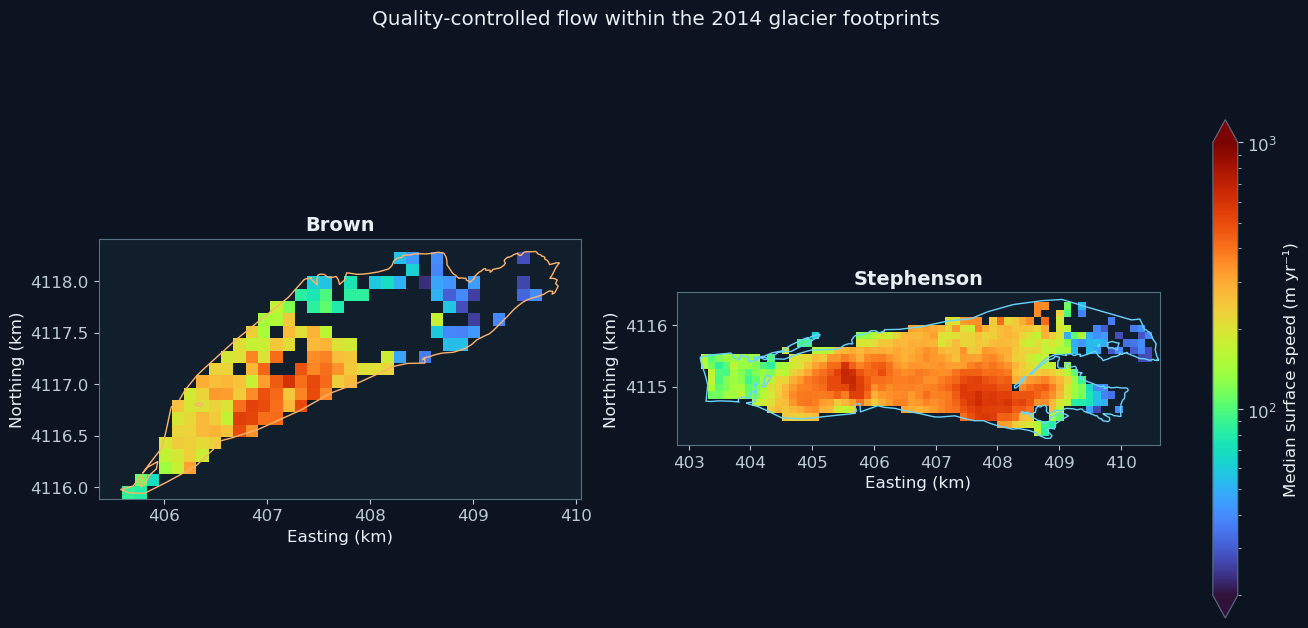

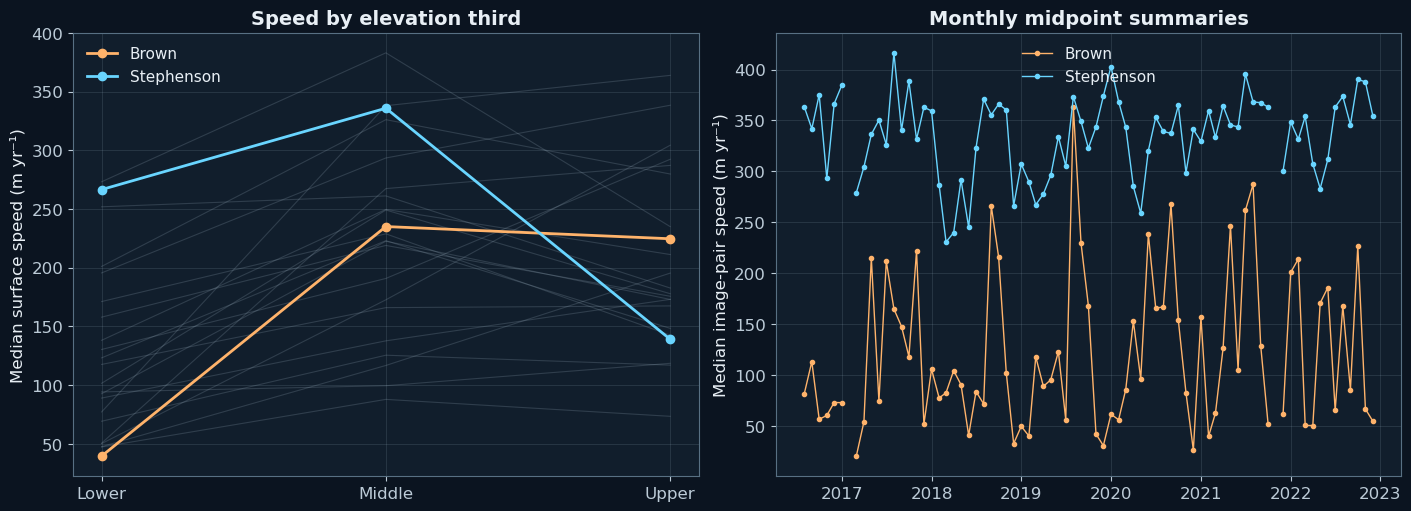

In [10]:
## Plot velocity maps, elevation profiles and time summaries ##

fig, axes = plt.subplots(
    1, 2, figsize = (13, 7), layout = "constrained")

normaliser = LogNorm(vmin = 20, vmax = 1000)

for axis, name in zip(axes, focus_names):
    glacier = velocity_glaciers.loc[
        velocity_glaciers["name_1"] == name].iloc[0]

    clipped = pixel_median_speed.rio.clip(
        [mapping(glacier.geometry)], working_crs, all_touched = False)

    image = axis.pcolormesh(
        clipped.x / 1000, clipped.y / 1000, clipped.values,
        cmap = "turbo", norm = normaliser, shading = "auto",
        rasterized = True)

    boundary = gpd.GeoSeries([glacier.geometry], crs = working_crs)

    # Scale only the figure coordinates; analysis remains in metres.
    boundary = boundary.scale(
        xfact = 0.001, yfact = 0.001, origin = (0, 0))

    boundary.boundary.plot(
        ax = axis, color = focus_colours[name], linewidth = 1)

    axis.set(
        aspect = "equal", xlabel = "Easting (km)",
        ylabel = "Northing (km)", title = name)

colourbar = fig.colorbar(image, ax = axes, shrink = 0.75, extend = "both")
colourbar.set_label("Median surface speed (m yr⁻¹)")

fig.suptitle("Quality-controlled flow within the 2014 glacier footprints")
fig.savefig(figure_dir / "07_velocity_focus_maps.png", dpi = 300)
fig.savefig(figure_dir / "07_velocity_focus_maps.svg")
plt.show()

fig, axes = plt.subplots(
    1, 2, figsize = (14, 5), layout = "constrained")

band_columns = [
    f"{band}_third_speed_m_yr" for band in ["lower", "middle", "upper"]]

for glacier in glacier_velocity_summary.itertuples():
    values = [getattr(glacier, column) for column in band_columns]

    axes[0].plot(
        [0, 1, 2], values, color = "#A8BDCD",
        alpha = 0.2, linewidth = 0.8)

for name in focus_names:
    row = glacier_velocity_summary.loc[
        glacier_velocity_summary["name_1"] == name].iloc[0]

    axes[0].plot(
        [0, 1, 2], row[band_columns].to_numpy(dtype = float),
        marker = "o", color = focus_colours[name],
        linewidth = 2, label = name)

    monthly = monthly_velocity_summary.loc[
        (monthly_velocity_summary["name_1"] == name) &
        (monthly_velocity_summary["elevation_band"] == "whole")].set_index("month")

    monthly = monthly.reindex(
        pd.date_range("2016-07-01", "2022-12-01", freq = "MS"))

    axes[1].plot(
        monthly.index, monthly["median_pair_speed_m_yr"],
        marker = ".", linewidth = 1,
        color = focus_colours[name], label = name)

axes[0].set(
    xticks = [0, 1, 2], xticklabels = ["Lower", "Middle", "Upper"],
    ylabel = "Median surface speed (m yr⁻¹)",
    title = "Speed by elevation third")

axes[1].set(
    ylabel = "Median image-pair speed (m yr⁻¹)",
    title = "Monthly midpoint summaries")

for axis in axes:
    axis.grid(alpha = 0.15)
    axis.legend()

fig.savefig(figure_dir / "07_velocity_profiles_and_time.png", dpi = 300)
fig.savefig(figure_dir / "07_velocity_profiles_and_time.svg")
plt.show()

In [11]:
## Export velocity summaries and spatial layers ##

summary_all = glacier_catalogue[["RGIId", "name_1"]].merge(
    glacier_velocity_summary.drop(columns = "name_1"),
    on = "RGIId", how = "left", validate = "one_to_one")

summary_all["status"] = np.select([
    summary_all["name_1"].isin(excluded_names),
    summary_all["retained_pixels"].fillna(0).eq(0)],
    ["excluded_from_original_sampling", "no_retained_velocity_pixels"],
    default = "analysed")

summary_all.to_csv(
    velocity_dir / "Heard_glacier_velocity_summary.csv", index = False)

elevational_velocity_summary.to_csv(
    velocity_dir / "Heard_velocity_elevation_bands.csv", index = False)

pair_velocity_summary.to_csv(
    velocity_dir / "Heard_focus_velocity_image_pairs.csv", index = False)

monthly_velocity_summary.to_csv(
    velocity_dir / "Heard_focus_velocity_monthly.csv", index = False)

timing = pd.DataFrame({
    "mid_date": raw_velocity.mid_date.values,
    "acquisition_date_img1": raw_velocity.acquisition_date_img1.values,
    "acquisition_date_img2": raw_velocity.acquisition_date_img2.values,
    "pair_duration_days": raw_velocity.date_dt.values / np.timedelta64(1, "D")})

timing.to_csv(
    velocity_dir / "Heard_velocity_selected_pairs.csv", index = False)

summary_geometry = glacier_catalogue.merge(
    summary_all.drop(columns = "name_1"),
    on = "RGIId", how = "left", validate = "one_to_one")

summary_geometry.to_file(
    velocity_dir / "Heard_velocity_summary.gpkg",
    layer = "velocity_2014_mask", driver = "GPKG")

summary_geometry.to_crs("EPSG:4326").to_file(
    map_data_dir / "Heard_velocity_summary.geojson", driver = "GeoJSON")

layers = {
    "median_speed": (pixel_median_speed, "m yr-1"),
    "median_vx": (pixel_median_vx, "m yr-1"),
    "median_vy": (pixel_median_vy, "m yr-1"),
    "lower_third_speed": (lower_third_speed, "m yr-1"),
    "raw_observation_count": (raw_count, "image pairs"),
    "filtered_observation_count": (filtered_count, "image pairs"),
    "vector_coherence": (vvc, "1"),
    "quality_mask": (quality_layer, "0 rejected; 1 retained"),
    "dem_120m": (
        dem_on_velocity_grid.where(elevation_band_layer.notnull()), "m"),
    "elevation_band": (elevation_band_layer, "1 lower; 2 middle; 3 upper"),
    "year_balanced_speed": (balanced_pixel_speed, "m yr-1"),
    "years_represented": (years_represented, "years, 2017-2022")}

def write_raster(layer, path, units):
    output = spatial_layer(layer).astype("float32").fillna(-9999)
    output.encoding = {}
    output = output.rio.write_nodata(-9999)

    output.rio.to_raster(
        path, compress = "deflate", dtype = "float32",
        tags = {
            "units": units,
            "sampling_inventory": "2014",
            "workflow": "07_Velocity"})

for name, (layer, units) in layers.items():
    write_raster(layer, velocity_dir / f"Heard_{name}.tif", units)

print(f"Saved tables and {len(layers)} island-wide spatial layers.")

Saved tables and 12 island-wide spatial layers.


In [12]:
## Segment velocity layers by glacier and save provenance ##

glacier_exports = {}
status_lookup = summary_all.set_index("RGIId")["status"]

for glacier in glacier_catalogue.itertuples():
    record = {
        "name": glacier.name_1,
        "status": status_lookup[glacier.RGIId],
        "layers": {}}

    if glacier.RGIId in glacier_masks:
        destination = velocity_dir / "by_glacier" / glacier.RGIId
        destination.mkdir(parents = True, exist_ok = True)

        for name, (layer, units) in layers.items():
            clipped = spatial_layer(layer).rio.clip(
                [mapping(glacier.geometry)], working_crs,
                all_touched = False, drop = True)

            path = destination / f"{name}.tif"
            write_raster(clipped, path, units)

            record["layers"][name] = path.relative_to(project_root).as_posix()

    glacier_exports[glacier.RGIId] = record

metadata = {
    "settings": settings,
    "sources": source_metadata["sources"],
    "dem": dem_path.relative_to(project_root).as_posix(),
    "crs": working_crs,
    "resolution_m": list(pixel_median_speed.rio.resolution()),
    "selected_image_pairs": raw_velocity.sizes["mid_date"],
    "primary_statistic":
        "Spatial median of pixelwise temporal-median accepted speeds",
    "coverage_definition":
        "100 * retained grid cells / cells with at least one finite positive raw vector inside the sampling mask",
    "elevation_bands":
        "Equal thirds of each glacier's DEM-derived elevation range",
    "monthly_statistic":
        "Median of per-pair spatial medians, grouped by image-pair midpoint month",
    "vvc_definition":
        "Length of the mean unit velocity vector after magnitude and direction filtering",
    "year_balanced_window":
        "2017-2022; median of available annual pixel medians",
    "limitations": [
        "Fixed 2014 sampling footprints include areas that subsequently deglaciated",
        "Image-pair speeds average motion over 10-180 days; pairs can overlap",
        "The >10 m/yr median-vector filter removes slow or stationary flow",
        "Elevation bands use a 2002 DEM, rather than a contemporaneous 2016-2022 surface",
        "Historical retreat and modern flow cover different periods"],
    "glaciers": glacier_exports}

(velocity_dir / "velocity_metadata.json").write_text(
    json.dumps(metadata, indent = 2), encoding = "utf-8")

(map_data_dir / "velocity_layers.json").write_text(
    json.dumps(metadata, indent = 2), encoding = "utf-8")

print(f"Map catalogue: {len(glacier_exports)} glacier records.")
print(f"Raster sets: {len(glacier_masks)} sampled glaciers, keyed by RGIId.")

Map catalogue: 23 glacier records.
Raster sets: 22 sampled glaciers, keyed by RGIId.


In [13]:
## Align surface slope and aspect with the velocity grid ##

terrain_dir = processed_dir / "geomorphology" / "terrain"
surface_slope_path = terrain_dir / "slope.tif"
surface_aspect_path = terrain_dir / "aspect.tif"

for path in [surface_slope_path, surface_aspect_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"Run the surface terrain derivative cell in 04 first: {path}")

def terrain_average(layer):
    layer = layer.copy()
    layer.encoding = {}
    layer = layer.rio.write_nodata(np.nan)

    return spatial_layer(layer.rio.reproject_match(
        pixel_median_speed, resampling = Resampling.average))

with rioxarray.open_rasterio(surface_slope_path, masked = True) as source:
    native_slope = source.squeeze(drop = True)

    surface_slope_120m = terrain_average(native_slope.where(
        (native_slope >= 0) & (native_slope <= 90)))

with rioxarray.open_rasterio(surface_aspect_path, masked = True) as source:
    native_aspect = source.squeeze(drop = True)

    angles = np.deg2rad(native_aspect.where(
        (native_aspect >= 0) & (native_aspect <= 360)))

    northness_120m = terrain_average(np.cos(angles))
    eastness_120m = terrain_average(np.sin(angles))

aspect_strength_120m = spatial_layer(np.hypot(
    northness_120m, eastness_120m).clip(min = 0, max = 1))

surface_aspect_120m = spatial_layer((np.rad2deg(np.arctan2(
    eastness_120m, northness_120m)) % 360).where(aspect_strength_120m > 1e-6))

print("Surface terrain aligned; aspect is degrees clockwise from north.")

Surface terrain aligned; aspect is degrees clockwise from north.


In [14]:
## Compare terrain across full footprints and retained velocity cells ##

def summarise_terrain(mask):
    inside = mask.values.astype(bool)

    slopes = surface_slope_120m.values[inside]
    slopes = slopes[np.isfinite(slopes)]

    north = northness_120m.values[inside]
    east = eastness_120m.values[inside]
    valid = np.isfinite(north) & np.isfinite(east)

    mean_north = float(north[valid].mean()) if valid.any() else np.nan
    mean_east = float(east[valid].mean()) if valid.any() else np.nan
    strength = float(np.clip(np.hypot(mean_north, mean_east), 0, 1))

    direction = (
        float(np.rad2deg(np.arctan2(mean_east, mean_north)) % 360)
        if strength > 1e-6 else np.nan)

    return {
        "mask_pixels": int(inside.sum()),
        "slope_pixels": int(slopes.size),
        "slope_median_deg": float(np.median(slopes)) if slopes.size else np.nan,
        "slope_p25_deg": float(np.percentile(slopes, 25)) if slopes.size else np.nan,
        "slope_p75_deg": float(np.percentile(slopes, 75)) if slopes.size else np.nan,
        "aspect_pixels": int(valid.sum()),
        "aspect_mean_deg": direction,
        "aspect_resultant_R": strength}

terrain_records = []

for glacier in velocity_glaciers.itertuples():
    masks = {
        "whole": glacier_masks[glacier.RGIId],
        **band_masks[glacier.RGIId]}

    for band, mask in masks.items():
        supports = {
            "2014 footprint": mask,
            "retained velocity": mask & pixel_median_speed.notnull()}

        for support, support_mask in supports.items():
            terrain_records.append({
                "RGIId": glacier.RGIId,
                "name_1": glacier.name_1,
                "elevation_band": band,
                "support": support,
                **summarise_terrain(support_mask)})

velocity_terrain_summary = pd.DataFrame(terrain_records)

velocity_terrain_summary.to_csv(
    velocity_dir / "Heard_velocity_terrain_summary.csv", index = False)

focus_terrain = velocity_terrain_summary.loc[
    velocity_terrain_summary["name_1"].isin(focus_names) &
    velocity_terrain_summary["elevation_band"].isin(["whole", "lower"])]

display(focus_terrain[[
    "name_1", "elevation_band", "support", "slope_pixels",
    "slope_median_deg", "aspect_mean_deg", "aspect_resultant_R"]].round(2))

,name_1,elevation_band,support,slope_pixels,slope_median_deg,aspect_mean_deg,aspect_resultant_R
32,Stephenson,whole,2014 footprint,636,16.40,91.41,0.66
33,Stephenson,whole,retained velocity,582,17.39,91.37,0.67
34,Stephenson,lower,2014 footprint,370,14.51,99.99,0.62
35,Stephenson,lower,retained velocity,316,15.85,101.29,0.63
168,Brown,whole,2014 footprint,238,13.06,45.56,0.81
169,Brown,whole,retained velocity,154,12.73,41.15,0.85
170,Brown,lower,2014 footprint,65,14.90,51.23,0.77
171,Brown,lower,retained velocity,25,14.19,41.01,0.76


In [15]:
## Export terrain layers into the glacier map catalogue ##

terrain_layers = {
    "surface_slope_120m": (surface_slope_120m, "degrees"),
    "surface_aspect_120m": (surface_aspect_120m, "degrees clockwise from north"),
    "surface_aspect_strength_120m": (
        aspect_strength_120m, "0-1; local directional agreement")}

for name, (layer, units) in terrain_layers.items():
    layer = layer.where(elevation_band_layer.notnull())
    write_raster(layer, velocity_dir / f"Heard_{name}.tif", units)

    for glacier in velocity_glaciers.itertuples():
        clipped = layer.rio.clip(
            [mapping(glacier.geometry)], working_crs, all_touched = False)

        path = velocity_dir / "by_glacier" / glacier.RGIId / f"{name}.tif"
        write_raster(clipped, path, units)

        metadata["glaciers"][glacier.RGIId]["layers"][name] = (
            path.relative_to(project_root).as_posix())

metadata["surface_terrain"] = {
    "slope_source": surface_slope_path.relative_to(project_root).as_posix(),
    "aspect_source": surface_aspect_path.relative_to(project_root).as_posix(),
    "aggregation":
        "Mean native-grid slopes; aspects aggregated through mean sine and cosine",
    "summary_supports": ["2014 footprint", "retained velocity"],
    "aspect_resultant_R":
        "Length of the mean aspect vector; near 1 consistent, near 0 mixed"}

for path in [
    velocity_dir / "velocity_metadata.json",
    map_data_dir / "velocity_layers.json"]:

    path.write_text(json.dumps(metadata, indent = 2), encoding = "utf-8")

print("Saved terrain summaries and three terrain layers for every sampled glacier.")

Saved terrain summaries and three terrain layers for every sampled glacier.


In [16]:
## Trace lower-third pixel losses through the velocity filters ##

stages = [
    ("2014 lower-third cells", None),
    ("Raw velocity observed", raw_count.notnull()),
    ("Magnitude filter", magnitude_mask.any("mid_date")),
    ("Median vector above 10 m/yr",
        median_vector_speed > settings["minimum_median_vector_speed_m_yr"]),
    ("Direction filter", direction_mask.any("mid_date")),
    ("At least five observations",
        filtered_count >= settings["minimum_observations"]),
    ("Vector coherence", vvc >= settings["minimum_vvc"])]

audit_records = []

for glacier in velocity_glaciers.loc[
    velocity_glaciers["name_1"].isin(focus_names)].itertuples():

    mask = band_masks[glacier.RGIId]["lower"]
    surviving = mask.copy()
    total = int(mask.sum().item())

    for label, condition in stages:
        if condition is not None:
            surviving = surviving & condition

        remaining = int(surviving.sum().item())

        audit_records.append({
            "RGIId": glacier.RGIId,
            "name_1": glacier.name_1,
            "stage": label,
            "pixels_remaining": remaining,
            "percent_of_lower_band":
                100 * remaining / total if total else np.nan})

    expected = mask & pixel_median_speed.notnull()

    assert np.array_equal(
        surviving.values, expected.values), "Audit disagrees with final velocity mask."

velocity_filter_audit = pd.DataFrame(audit_records)

velocity_filter_audit.to_csv(
    velocity_dir / "Heard_focus_lower_third_filter_audit.csv", index = False)

display(velocity_filter_audit.pivot(
    index = "stage", columns = "name_1", values = "pixels_remaining").reindex(
    [label for label, _ in stages]))

name_1,Brown,Stephenson
stage,,
2014 lower-third cells,65,370
Raw velocity observed,65,370
Magnitude filter,65,370
Median vector above 10 m/yr,37,345
Direction filter,37,345
At least five observations,25,316
Vector coherence,25,316


In [17]:
## Test velocity thresholds without replacing the main results ##

def trial_vector_quality(mask):
    selected_speed = raw_velocity["speed"].where(mask)
    count = mask.sum("mid_date")
    count = count.where(count > 0)

    unit_x = raw_velocity["vx"].where(mask) / selected_speed
    unit_y = raw_velocity["vy"].where(mask) / selected_speed

    coherence = np.hypot(
        unit_x.sum("mid_date", skipna = True),
        unit_y.sum("mid_date", skipna = True)) / count

    return count, coherence.clip(min = 0, max = 1)

# Rebuild direction selection without the speed floor.
trial_direction = magnitude_mask & (denominator > 0) & (
    direction_cosine > np.cos(np.deg2rad(settings["direction_degrees"])))

trial_count, trial_vvc = trial_vector_quality(trial_direction)
_, pre_direction_vvc = trial_vector_quality(magnitude_mask)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

    trial_median = spatial_layer(raw_velocity["speed"].where(
        trial_direction).median("mid_date", skipna = True))

# Check that rebuilding the filters reproduces the current result.
baseline_mask = (
    (median_vector_speed > settings["minimum_median_vector_speed_m_yr"]) &
    (trial_count >= settings["minimum_observations"]) &
    (trial_vvc >= settings["minimum_vvc"]))

np.testing.assert_allclose(
    trial_median.where(baseline_mask).values,
    pixel_median_speed.values, equal_nan = True)

sensitivity_records = []

for speed_floor in [10, 5, 0]:
    for minimum_pairs in [5, 3]:
        accepted = (
            (median_vector_speed > speed_floor) &
            (trial_count >= minimum_pairs) &
            (trial_vvc >= settings["minimum_vvc"]))

        candidate = trial_median.where(accepted)

        for glacier in velocity_glaciers.itertuples():
            masks = {
                "whole": glacier_masks[glacier.RGIId],
                "lower": band_masks[glacier.RGIId]["lower"]}

            for band, mask in masks.items():
                inside = mask.values

                values = candidate.values[
                    inside & np.isfinite(candidate.values)]

                observed = int((mask & raw_count.notnull()).sum().item())

                new_cells = (
                    mask & candidate.notnull() & pixel_median_speed.isnull())

                new_vvc = pre_direction_vvc.values[new_cells.values]
                new_vvc = new_vvc[np.isfinite(new_vvc)]

                sensitivity_records.append({
                    "RGIId": glacier.RGIId,
                    "name_1": glacier.name_1,
                    "elevation_band": band,
                    "speed_floor_m_yr": speed_floor,
                    "minimum_pairs": minimum_pairs,
                    "observed_pixels": observed,
                    "retained_pixels": int(values.size),
                    "coverage_percent":
                        100 * values.size / observed if observed else np.nan,
                    "median_speed_m_yr":
                        float(np.median(values)) if values.size else np.nan,
                    "new_pixels": int(new_cells.sum().item()),
                    "new_pixels_pre_direction_vvc":
                        float(np.median(new_vvc)) if new_vvc.size else np.nan})

velocity_threshold_sensitivity = pd.DataFrame(sensitivity_records)

velocity_threshold_sensitivity.to_csv(
    velocity_dir / "Heard_velocity_threshold_sensitivity.csv", index = False)

focus_sensitivity = velocity_threshold_sensitivity.loc[
    velocity_threshold_sensitivity["name_1"].isin(focus_names) &
    velocity_threshold_sensitivity["elevation_band"].eq("lower")]

display(focus_sensitivity[[
    "name_1", "speed_floor_m_yr", "minimum_pairs",
    "retained_pixels", "coverage_percent", "median_speed_m_yr",
    "new_pixels_pre_direction_vvc"]].round(2))

,name_1,speed_floor_m_yr,minimum_pairs,retained_pixels,coverage_percent,median_speed_m_yr,new_pixels_pre_direction_vvc
9,Stephenson,10,5,316,85.41,266.52,NaN
43,Brown,10,5,25,38.46,39.57,NaN
53,Stephenson,10,3,325,87.84,263.99,0.38
87,Brown,10,3,32,49.23,41.14,0.50
97,Stephenson,5,5,331,89.46,261.31,0.08
131,Brown,5,5,46,70.77,32.14,0.08
141,Stephenson,5,3,341,92.16,258.77,0.10
175,Brown,5,3,54,83.08,35.59,0.10
185,Stephenson,0,5,338,91.35,258.07,0.09
219,Brown,0,5,52,80.00,32.25,0.07


In [18]:
## Retrieve errors for the cached velocity observations ##

error_cache_path = cache_dir / f"Heard_S1A_{cache_key}_v_error.zarr"
sampling = source_metadata["selection"]

if not error_cache_path.exists():
    error_tiles = []

    for side, url in source_metadata["sources"].items():
        options = {"anon": True} if url.startswith("s3://") else None

        with xr.open_zarr(
            url, chunks = "auto", decode_timedelta = True,
            storage_options = options) as cube:

            if "v_error" not in cube:
                raise KeyError(f"No v_error field in the {side} datacube.")

            if int(cube["mapping"].attrs["spatial_epsg"]) != 32743:
                raise ValueError(f"Unexpected projection in the {side} datacube.")

            pair_mask = (
                cube["mid_date"].isin(raw_velocity.mid_date.values) &
                (cube["acquisition_date_img1"] >= np.datetime64(sampling["start_inclusive"])) &
                (cube["acquisition_date_img2"] < np.datetime64(sampling["end_exclusive"])) &
                (cube["date_dt"] >= np.timedelta64(sampling["minimum_pair_days"], "D")) &
                (cube["date_dt"] <= np.timedelta64(sampling["maximum_pair_days"], "D")) &
                (cube["satellite_img1"].astype(str) == sampling["satellite"]) &
                (cube["satellite_img2"].astype(str) == sampling["satellite"]))

            selected = cube.isel(
                mid_date = np.flatnonzero(pair_mask.values)).sortby("mid_date")

            for name in [
                "mid_date", "acquisition_date_img1",
                "acquisition_date_img2", "date_dt"]:

                if not np.array_equal(selected[name].values, raw_velocity[name].values):
                    raise ValueError(
                        f"Error observations disagree with the velocity cache: {side}, {name}.")

            error = selected["v_error"].rio.set_spatial_dims(
                x_dim = "x", y_dim = "y").rio.write_crs(working_crs)

            error = error.rio.clip_box(*raw_velocity.rio.bounds())

            print(f"Downloading the {side} error field...")

            with ProgressBar():
                error_tiles.append(error.load())

    errors = xr.concat(error_tiles, dim = "x", join = "exact").sortby("x")

    for coordinate in ["mid_date", "x", "y"]:
        if not np.array_equal(errors[coordinate].values, raw_velocity[coordinate].values):
            raise ValueError(f"Error and velocity grids disagree on {coordinate}.")

    error_dataset = errors.where(raw_count.notnull()).to_dataset(name = "v_error")
    error_dataset = error_dataset.chunk({"mid_date": -1, "y": 128, "x": 128})

    for name in error_dataset.variables:
        error_dataset[name].encoding = {}

    format_argument = (
        "zarr_format" if "zarr_format" in inspect.signature(xr.Dataset.to_zarr).parameters
        else "zarr_version")

    with tempfile.TemporaryDirectory(dir = cache_dir) as temporary_dir:
        staging_path = Path(temporary_dir) / "errors.zarr"

        error_dataset.to_zarr(
            staging_path, mode = "w", consolidated = True,
            **{format_argument: 2})

        staging_path.rename(error_cache_path)

with xr.open_zarr(error_cache_path, chunks = None) as cached_errors:
    velocity_error = cached_errors["v_error"].load().transpose("mid_date", "y", "x")

print("Velocity-error data ready; the original velocity cache was reused.")

[########################################] | 100% Completed | 20.70 s
[########################################] | 100% Completed | 38.31 s
Velocity-error data ready; the original velocity cache was reused.


In [19]:
## Summarise supplied errors for accepted velocity observations ##

error_supported = (
    analysis_velocity["speed"].notnull() &
    np.isfinite(velocity_error) & (velocity_error > 0))

accepted_error = velocity_error.where(error_supported)

pair_speed_error_ratio = (
    analysis_velocity["speed"] / accepted_error).where(error_supported)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message = "All-NaN slice encountered", category = RuntimeWarning)

    pixel_median_pair_error = spatial_layer(
        accepted_error.median("mid_date", skipna = True))

    pixel_median_pair_ratio = spatial_layer(
        pair_speed_error_ratio.median("mid_date", skipna = True))

error_records = []

for glacier in velocity_glaciers.itertuples():
    masks = {
        "whole": glacier_masks[glacier.RGIId],
        **band_masks[glacier.RGIId]}

    for band, mask in masks.items():
        values = pixel_median_pair_error.values[mask.values]
        values = values[np.isfinite(values)]

        ratios = pixel_median_pair_ratio.values[mask.values]
        ratios = ratios[np.isfinite(ratios)]

        error_records.append({
            "RGIId": glacier.RGIId,
            "name_1": glacier.name_1,
            "elevation_band": band,
            "error_supported_pixels": int(values.size),
            "median_pair_error_m_yr":
                float(np.median(values)) if values.size else np.nan,
            "median_pair_speed_error_ratio":
                float(np.median(ratios)) if ratios.size else np.nan})

velocity_error_summary = pd.DataFrame(error_records)

velocity_error_summary.to_csv(
    velocity_dir / "Heard_velocity_error_summary.csv", index = False)

display(velocity_error_summary.loc[
    velocity_error_summary["name_1"].isin(focus_names) &
    velocity_error_summary["elevation_band"].isin(["whole", "lower"])].round(2))

error_layers = {
    "median_pair_error": (
        pixel_median_pair_error, "m yr-1; supplied individual-pair error"),
    "median_pair_speed_error_ratio": (
        pixel_median_pair_ratio, "1; individual-pair speed / supplied error")}

for name, (layer, units) in error_layers.items():
    write_raster(layer, velocity_dir / f"Heard_{name}.tif", units)

    for glacier in velocity_glaciers.itertuples():
        clipped = layer.rio.clip(
            [mapping(glacier.geometry)], working_crs, all_touched = False)

        path = velocity_dir / "by_glacier" / glacier.RGIId / f"{name}.tif"
        write_raster(clipped, path, units)

        metadata["glaciers"][glacier.RGIId]["layers"][name] = (
            path.relative_to(project_root).as_posix())

metadata["velocity_error"] = {
    "source_variable": "ITS_LIVE v_error",
    "summary_csv": (
        velocity_dir / "Heard_velocity_error_summary.csv"
        ).relative_to(project_root).as_posix(),
    "statistic":
        "Spatial median of pixelwise temporal medians for accepted observations",
    "interpretation":
        "Errors describe individual image pairs, not uncertainty or a confidence interval for the pooled glacier median",
    "threshold_test": {
        "speed_floors_m_yr": [0, 5, 10],
        "minimum_pairs": [3, 5],
        "selected_speed_floor_m_yr": settings["minimum_median_vector_speed_m_yr"],
        "selected_minimum_pairs": settings["minimum_observations"]}}

for path in [
    velocity_dir / "velocity_metadata.json",
    map_data_dir / "velocity_layers.json"]:

    path.write_text(json.dumps(metadata, indent = 2), encoding = "utf-8")

print("Saved uncertainty diagnostics and their glacier-specific map layers.")

,RGIId,name_1,elevation_band,error_supported_pixels,median_pair_error_m_yr,median_pair_speed_error_ratio
16,RGI60-19.00005,Stephenson,whole,582,95.0,2.98
17,RGI60-19.00005,Stephenson,lower,316,96.0,2.82
84,RGI60-19.00023,Brown,whole,154,88.5,2.29
85,RGI60-19.00023,Brown,lower,25,75.5,0.56


Saved uncertainty diagnostics and their glacier-specific map layers.
